# Crop Recommendation Model Training with 5-Fold Stratified Cross Validation

In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    cohen_kappa_score, matthews_corrcoef, log_loss,
    classification_report, confusion_matrix
)

In [2]:
csv_path = os.path.join("..", "dataset", "Crop Recommendation dataset.csv")
if not os.path.exists(csv_path):
    csv_path = os.path.join("dataset", "Crop Recommendation dataset.csv")

df = pd.read_csv(csv_path)
print("Dataset Shape:", df.shape)
print("Target Classes (" + str(df["label"].nunique()) + "):", df["label"].unique())
df.head()

Dataset Shape: (2200, 8)
Target Classes (22): ['rice' 'maize' 'chickpea' 'kidneybeans' 'pigeonpeas' 'mothbeans'
 'mungbean' 'blackgram' 'lentil' 'pomegranate' 'banana' 'mango' 'grapes'
 'watermelon' 'muskmelon' 'apple' 'orange' 'papaya' 'coconut' 'cotton'
 'jute' 'coffee']


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [3]:
feature_cols = ["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]
X = df[feature_cols].values
y_raw = df["label"].values

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features Shape:", X_scaled.shape)
print("Labels Shape:", y.shape)

Features Shape: (2200, 7)
Labels Shape: (2200,)


In [4]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_metrics = {
    "Fold": [],
    "Accuracy": [],
    "Precision_Macro": [],
    "Recall_Macro": [],
    "F1_Macro": [],
    "Cohen_Kappa": [],
    "MCC": [],
    "Log_Loss": []
}

oof_predictions = np.zeros(len(y), dtype=int)
oof_probabilities = np.zeros((len(y), len(label_encoder.classes_)))
feature_importances_list = []
best_model = None
best_acc = 0.0

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train, y_train = X[train_idx], y[train_idx]
    X_val, y_val = X[val_idx], y[val_idx]

    fold_scaler = StandardScaler()
    X_train_scaled = fold_scaler.fit_transform(X_train)
    X_val_scaled = fold_scaler.transform(X_val)

    clf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
    clf.fit(X_train_scaled, y_train)

    preds = clf.predict(X_val_scaled)
    probs = clf.predict_proba(X_val_scaled)

    oof_predictions[val_idx] = preds
    oof_probabilities[val_idx] = probs
    feature_importances_list.append(clf.feature_importances_)

    acc = accuracy_score(y_val, preds)
    prec = precision_score(y_val, preds, average="macro", zero_division=0)
    rec = recall_score(y_val, preds, average="macro", zero_division=0)
    f1 = f1_score(y_val, preds, average="macro", zero_division=0)
    kappa = cohen_kappa_score(y_val, preds)
    mcc = matthews_corrcoef(y_val, preds)
    loss = log_loss(y_val, probs)

    fold_metrics["Fold"].append(f"Fold {fold}")
    fold_metrics["Accuracy"].append(acc)
    fold_metrics["Precision_Macro"].append(prec)
    fold_metrics["Recall_Macro"].append(rec)
    fold_metrics["F1_Macro"].append(f1)
    fold_metrics["Cohen_Kappa"].append(kappa)
    fold_metrics["MCC"].append(mcc)
    fold_metrics["Log_Loss"].append(loss)

    print(f"Fold {fold}/5 - Acc: {acc * 100:.2f}% | F1: {f1 * 100:.2f}% | Kappa: {kappa:.4f} | MCC: {mcc:.4f} | Loss: {loss:.4f}")

    if acc > best_acc:
        best_acc = acc
        best_model = clf

metrics_df = pd.DataFrame(fold_metrics)
mean_row = pd.DataFrame({
    "Fold": ["Mean (+/- Std)"],
    "Accuracy": [f"{metrics_df['Accuracy'].mean() * 100:.2f}% (+/- {metrics_df['Accuracy'].std() * 100:.2f}%)"],
    "Precision_Macro": [f"{metrics_df['Precision_Macro'].mean() * 100:.2f}% (+/- {metrics_df['Precision_Macro'].std() * 100:.2f}%)"],
    "Recall_Macro": [f"{metrics_df['Recall_Macro'].mean() * 100:.2f}% (+/- {metrics_df['Recall_Macro'].std() * 100:.2f}%)"],
    "F1_Macro": [f"{metrics_df['F1_Macro'].mean() * 100:.2f}% (+/- {metrics_df['F1_Macro'].std() * 100:.2f}%)"],
    "Cohen_Kappa": [f"{metrics_df['Cohen_Kappa'].mean():.4f} (+/- {metrics_df['Cohen_Kappa'].std():.4f})"],
    "MCC": [f"{metrics_df['MCC'].mean():.4f} (+/- {metrics_df['MCC'].std():.4f})"],
    "Log_Loss": [f"{metrics_df['Log_Loss'].mean():.4f} (+/- {metrics_df['Log_Loss'].std():.4f})"]
})

print("\n=== 5-Fold Stratified Cross Validation Summary ===")
print(metrics_df.to_string(index=False))
print("\nOverall Aggregates:")
print(mean_row.to_string(index=False))

Fold 1/5 - Acc: 99.55% | F1: 99.54% | Kappa: 0.9952 | MCC: 0.9953 | Loss: 0.0514
Fold 2/5 - Acc: 99.32% | F1: 99.32% | Kappa: 0.9929 | MCC: 0.9929 | Loss: 0.0506
Fold 3/5 - Acc: 99.77% | F1: 99.77% | Kappa: 0.9976 | MCC: 0.9976 | Loss: 0.0501
Fold 4/5 - Acc: 99.77% | F1: 99.77% | Kappa: 0.9976 | MCC: 0.9976 | Loss: 0.0547
Fold 5/5 - Acc: 99.09% | F1: 99.09% | Kappa: 0.9905 | MCC: 0.9905 | Loss: 0.0523

=== 5-Fold Stratified Cross Validation Summary ===
  Fold  Accuracy  Precision_Macro  Recall_Macro  F1_Macro  Cohen_Kappa      MCC  Log_Loss
Fold 1  0.995455         0.995868      0.995455  0.995443     0.995238 0.995260  0.051382
Fold 2  0.993182         0.993703      0.993182  0.993169     0.992857 0.992884  0.050561
Fold 3  0.997727         0.997835      0.997727  0.997726     0.997619 0.997624  0.050121
Fold 4  0.997727         0.997835      0.997727  0.997726     0.997619 0.997624  0.054745
Fold 5  0.990909         0.991114      0.990909  0.990903     0.990476 0.990487  0.052259

Ov

In [5]:
print("=== Out-Of-Fold Classification Report ===")
print(classification_report(y, oof_predictions, target_names=label_encoder.classes_, digits=4))

=== Out-Of-Fold Classification Report ===
              precision    recall  f1-score   support

       apple     1.0000    1.0000    1.0000       100
      banana     1.0000    1.0000    1.0000       100
   blackgram     1.0000    0.9900    0.9950       100
    chickpea     1.0000    1.0000    1.0000       100
     coconut     1.0000    1.0000    1.0000       100
      coffee     1.0000    1.0000    1.0000       100
      cotton     1.0000    1.0000    1.0000       100
      grapes     1.0000    1.0000    1.0000       100
        jute     0.9333    0.9800    0.9561       100
 kidneybeans     1.0000    1.0000    1.0000       100
      lentil     0.9901    1.0000    0.9950       100
       maize     0.9901    1.0000    0.9950       100
       mango     1.0000    1.0000    1.0000       100
   mothbeans     1.0000    0.9900    0.9950       100
    mungbean     1.0000    1.0000    1.0000       100
   muskmelon     1.0000    1.0000    1.0000       100
      orange     1.0000    1.0000    1.

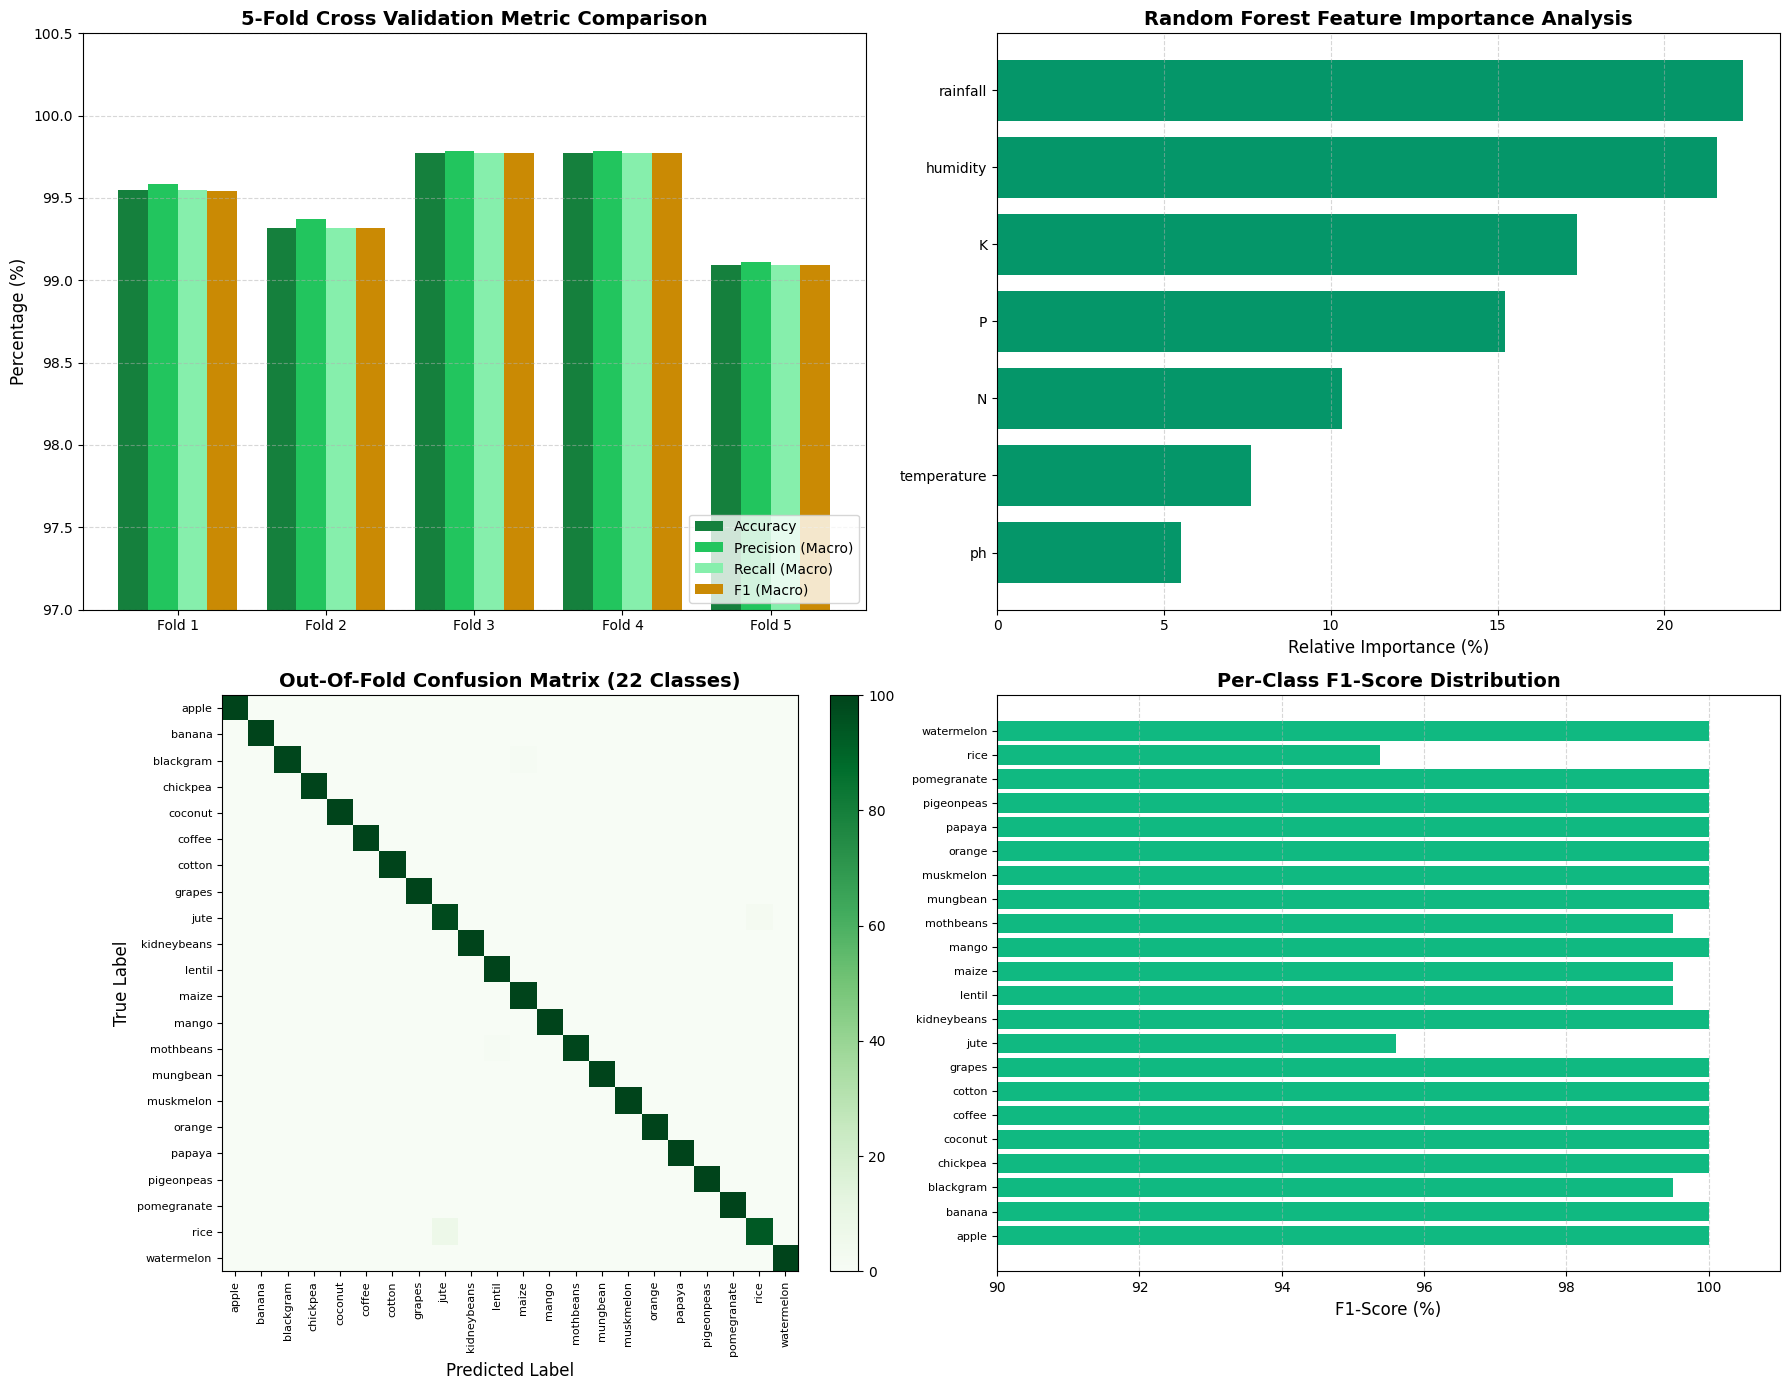

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# 1. Fold-wise Metrics Bar Chart
folds = [f'Fold {i}' for i in range(1, 6)]
x = np.arange(len(folds))
width = 0.2

axes[0, 0].bar(x - width*1.5, [v*100 for v in fold_metrics['Accuracy']], width, label='Accuracy', color='#15803d')
axes[0, 0].bar(x - width*0.5, [v*100 for v in fold_metrics['Precision_Macro']], width, label='Precision (Macro)', color='#22c55e')
axes[0, 0].bar(x + width*0.5, [v*100 for v in fold_metrics['Recall_Macro']], width, label='Recall (Macro)', color='#86efac')
axes[0, 0].bar(x + width*1.5, [v*100 for v in fold_metrics['F1_Macro']], width, label='F1 (Macro)', color='#ca8a04')
axes[0, 0].set_ylabel('Percentage (%)', fontsize=12)
axes[0, 0].set_title('5-Fold Cross Validation Metric Comparison', fontsize=14, fontweight='bold')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(folds)
axes[0, 0].set_ylim(97, 100.5)
axes[0, 0].legend(loc='lower right')
axes[0, 0].grid(axis='y', linestyle='--', alpha=0.5)

# 2. Random Forest Feature Importance Chart
mean_importances = np.mean(feature_importances_list, axis=0)
sorted_idx = np.argsort(mean_importances)
axes[0, 1].barh(np.array(feature_cols)[sorted_idx], mean_importances[sorted_idx] * 100, color='#059669')
axes[0, 1].set_xlabel('Relative Importance (%)', fontsize=12)
axes[0, 1].set_title('Random Forest Feature Importance Analysis', fontsize=14, fontweight='bold')
axes[0, 1].grid(axis='x', linestyle='--', alpha=0.5)

# 3. Confusion Matrix Heatmap
cm = confusion_matrix(y, oof_predictions)
im = axes[1, 0].imshow(cm, interpolation='nearest', cmap=plt.cm.Greens)
axes[1, 0].set_title('Out-Of-Fold Confusion Matrix (22 Classes)', fontsize=14, fontweight='bold')
tick_marks = np.arange(len(label_encoder.classes_))
axes[1, 0].set_xticks(tick_marks)
axes[1, 0].set_yticks(tick_marks)
axes[1, 0].set_xticklabels(label_encoder.classes_, rotation=90, fontsize=8)
axes[1, 0].set_yticklabels(label_encoder.classes_, fontsize=8)
axes[1, 0].set_ylabel('True Label', fontsize=12)
axes[1, 0].set_xlabel('Predicted Label', fontsize=12)
fig.colorbar(im, ax=axes[1, 0], fraction=0.046, pad=0.04)

# 4. Per-Class F1-Score Horizontal Bar Chart
report_dict = classification_report(y, oof_predictions, target_names=label_encoder.classes_, output_dict=True)
class_f1 = [report_dict[c]['f1-score'] * 100 for c in label_encoder.classes_]
axes[1, 1].barh(label_encoder.classes_, class_f1, color='#10b981')
axes[1, 1].set_xlabel('F1-Score (%)', fontsize=12)
axes[1, 1].set_title('Per-Class F1-Score Distribution', fontsize=14, fontweight='bold')
axes[1, 1].set_xlim(90, 101)
axes[1, 1].tick_params(axis='y', labelsize=8)
axes[1, 1].grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [7]:
final_model = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
final_model.fit(X_scaled, y)

full_train_acc = accuracy_score(y, final_model.predict(X_scaled))
print(f"Full Dataset Training Accuracy: {full_train_acc * 100:.2f}%")

weights_dir = "weights"
if not os.path.exists(weights_dir) and os.path.exists(os.path.join("..", "weights")):
    weights_dir = os.path.join("..", "weights")
os.makedirs(weights_dir, exist_ok=True)

output_pkl_path = os.path.join(weights_dir, "crop_model_final.pkl")
export_data = {
    "model": final_model,
    "scaler": scaler,
    "label_encoder": label_encoder,
    "accuracy": round(float(np.mean(fold_metrics['Accuracy'])), 4),
    "feature_cols": feature_cols
}

with open(output_pkl_path, "wb") as f:
    pickle.dump(export_data, f)

print(f"Exported crop recommendation model to: {output_pkl_path}")

src_crop_dir = os.path.join("src", "crop")
if not os.path.exists(src_crop_dir) and os.path.exists(os.path.join("..", "src", "crop")):
    src_crop_dir = os.path.join("..", "src", "crop")
if os.path.exists(src_crop_dir):
    alt_path = os.path.join(src_crop_dir, "crop_model_final.pkl")
    with open(alt_path, "wb") as f:
        pickle.dump(export_data, f)
    print(f"Synced model to: {alt_path}")

Full Dataset Training Accuracy: 100.00%
Exported crop recommendation model to: ..\weights\crop_model_final.pkl
Synced model to: ..\src\crop\crop_model_final.pkl


In [8]:
sample_input = [[90, 42, 43, 25.0, 80.0, 6.5, 200.0]]
sample_scaled = scaler.transform(sample_input)
pred_idx = final_model.predict(sample_scaled)[0]
probs = final_model.predict_proba(sample_scaled)[0]

top3_indices = np.argsort(probs)[::-1][:3]
print("Test Input: N=90, P=42, K=43, temp=25.0, hum=80.0, ph=6.5, rain=200.0")
print("Recommended Crop:", label_encoder.inverse_transform([pred_idx])[0])
print("Top 3 Predictions:")
for i in top3_indices:
    print(f"  - {label_encoder.inverse_transform([i])[0]}: {probs[i] * 100:.2f}%")

Test Input: N=90, P=42, K=43, temp=25.0, hum=80.0, ph=6.5, rain=200.0
Recommended Crop: jute
Top 3 Predictions:
  - jute: 51.00%
  - rice: 49.00%
  - watermelon: 0.00%
